In [17]:
!nvidia-smi

Tue Sep 29 14:04:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             31W /   70W |     201MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
from numba import cuda

print("CUDA available:", cuda.is_available())

CUDA available: True


Original image shape: (1920, 1080, 3)
Original image dtype: uint8
Image size: 1080 x 1920
Number of pixels: 2073600
Channels: 3
Flattened RGB shape: (2073600, 3)

CPU grayscale time: 2.1659090518951416 seconds


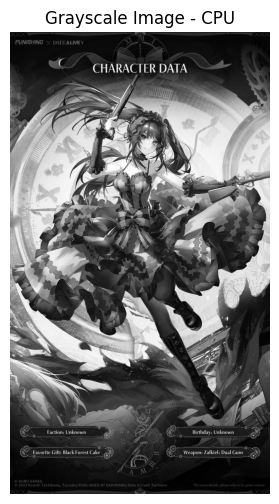


Threads per block: 256
Blocks per grid: 8100
GPU grayscale time: 0.0005943775177001953 seconds


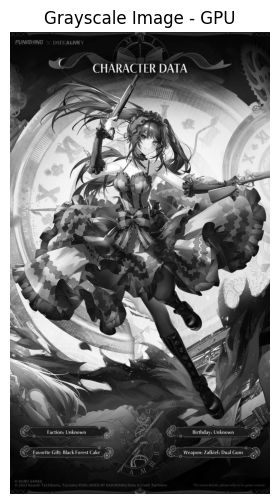



PERFORMANCE RESULTS
CPU time : 2.165909 seconds
GPU time : 0.000594 seconds
Speedup  : 3644.00x


VALIDATION
Maximum CPU-GPU difference: 3.0517578e-05
Mean CPU-GPU difference: 2.53544e-06
Validation: CPU and GPU results are the same.


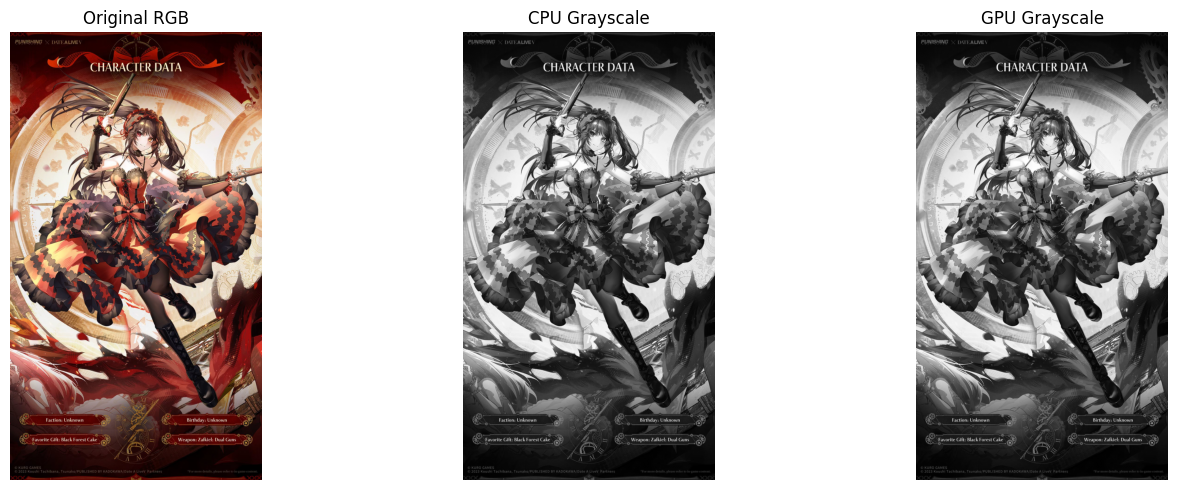

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from numba import cuda
import time

# 1. Load image
image_path = "/content/img.jpg"
img = mpimg.imread(image_path)

print("Original image shape:", img.shape)
print("Original image dtype:", img.dtype)

# 2. Prepare RGB image
# Remove alpha channel if the image is RGBA
if img.ndim == 3 and img.shape[2] == 4:
    img = img[:, :, :3]

# Convert to float32 for CUDA
img = img.astype(np.float32)

height, width, channels = img.shape
pixel_count = height * width

print("Image size:", width, "x", height)
print("Number of pixels:", pixel_count)
print("Channels:", channels)

# 3. Flatten image into (pixelCount, 3)
rgb_pixels = img.reshape(pixel_count, 3)

print("Flattened RGB shape:", rgb_pixels.shape)

# 4. CPU grayscale implementation

def grayscale_cpu(rgb):
    gray = np.empty(rgb.shape[0], dtype=np.float32)

    for i in range(rgb.shape[0]):
        r = rgb[i, 0]
        g = rgb[i, 1]
        b = rgb[i, 2]

        gray[i] = 0.299 * r + 0.587 * g + 0.114 * b

    return gray


start_cpu = time.time()

gray_cpu = grayscale_cpu(rgb_pixels)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu

gray_cpu_image = gray_cpu.reshape(height, width)

print("\nCPU grayscale time:", cpu_time, "seconds")

# 5. Display and save CPU result

plt.figure(figsize=(8, 6))
plt.imshow(gray_cpu_image, cmap="gray")
plt.title("Grayscale Image - CPU")
plt.axis("off")
plt.show()

plt.imsave("/content/gray_cpu.jpg", gray_cpu_image, cmap="gray")

# 6. GPU grayscale CUDA kernel

@cuda.jit
def grayscale_gpu(rgb, gray):

    i = cuda.grid(1)

    if i < rgb.shape[0]:

        r = rgb[i, 0]
        g = rgb[i, 1]
        b = rgb[i, 2]

        gray[i] = 0.299 * r + 0.587 * g + 0.114 * b

# 7. Allocate and copy data to GPU
d_rgb = cuda.to_device(rgb_pixels)
d_gray = cuda.device_array(pixel_count, dtype=np.float32)

# 8. Configure CUDA execution
threads_per_block = 256

blocks_per_grid = (
    pixel_count + threads_per_block - 1
) // threads_per_block

print("\nThreads per block:", threads_per_block)
print("Blocks per grid:", blocks_per_grid)

# 9. GPU grayscale execution
# Warm-up execution to initialize the CUDA kernel
grayscale_gpu[blocks_per_grid, threads_per_block](
    d_rgb,
    d_gray
)

cuda.synchronize()


# Measure GPU kernel execution time
start_gpu = time.time()

grayscale_gpu[blocks_per_grid, threads_per_block](
    d_rgb,
    d_gray
)

cuda.synchronize()

end_gpu = time.time()

gpu_time = end_gpu - start_gpu


# Copy result back to CPU
gray_gpu = d_gray.copy_to_host()

gray_gpu_image = gray_gpu.reshape(height, width)

print("GPU grayscale time:", gpu_time, "seconds")

# 10. Display and save GPU result
plt.figure(figsize=(8, 6))
plt.imshow(gray_gpu_image, cmap="gray")
plt.title("Grayscale Image - GPU")
plt.axis("off")
plt.show()

plt.imsave("/content/gray_gpu.jpg", gray_gpu_image, cmap="gray")

# 11. Calculate speedup
speedup = cpu_time / gpu_time

print("\n")
print("PERFORMANCE RESULTS")
print(f"CPU time : {cpu_time:.6f} seconds")
print(f"GPU time : {gpu_time:.6f} seconds")
print(f"Speedup  : {speedup:.2f}x")

# 12. Validate CPU and GPU results
difference = np.abs(gray_cpu - gray_gpu)

max_difference = np.max(difference)
mean_difference = np.mean(difference)

print("\n")
print("VALIDATION")
print("Maximum CPU-GPU difference:", max_difference)
print("Mean CPU-GPU difference:", mean_difference)

if np.allclose(gray_cpu, gray_gpu, atol=1e-5):
    print("Validation: CPU and GPU results are the same.")
else:
    print("Validation: CPU and GPU results are different.")

# 13. Display original, CPU and GPU results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img.astype(np.uint8))
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_cpu_image, cmap="gray")
plt.title("CPU Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_gpu_image, cmap="gray")
plt.title("GPU Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

Block size:   32 | Blocks: 64800 | Average time: 0.000857 s
Block size:   64 | Blocks: 32400 | Average time: 0.000436 s
Block size:  128 | Blocks: 16200 | Average time: 0.000404 s
Block size:  256 | Blocks:  8100 | Average time: 0.000401 s
Block size:  512 | Blocks:  4050 | Average time: 0.000406 s
Block size: 1024 | Blocks:  2025 | Average time: 0.000462 s


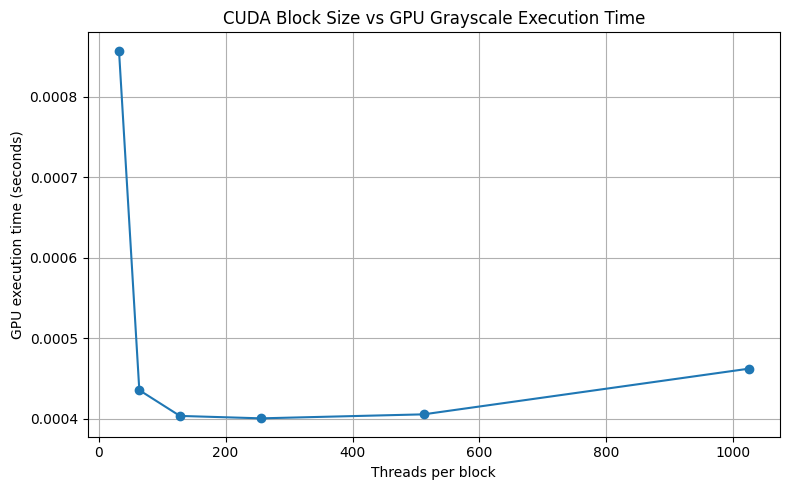

In [21]:
# Block size experiment

block_sizes = [32, 64, 128, 256, 512, 1024]
block_times = []

# Warm-up
grayscale_gpu[8100, 256](d_rgb, d_gray)
cuda.synchronize()

for threads_per_block in block_sizes:

    blocks_per_grid = (
        pixel_count + threads_per_block - 1
    ) // threads_per_block

    # Run several times to reduce timing noise
    times = []

    for _ in range(5):

        start = time.time()

        grayscale_gpu[
            blocks_per_grid,
            threads_per_block
        ](d_rgb, d_gray)

        cuda.synchronize()

        end = time.time()

        times.append(end - start)

    avg_time = np.mean(times)
    block_times.append(avg_time)

    print(
        f"Block size: {threads_per_block:4d} | "
        f"Blocks: {blocks_per_grid:5d} | "
        f"Average time: {avg_time:.6f} s"
    )

# Plot block size vs execution time
plt.figure(figsize=(8, 5))

plt.plot(
    block_sizes,
    block_times,
    marker="o"
)

plt.xlabel("Threads per block")
plt.ylabel("GPU execution time (seconds)")
plt.title("CUDA Block Size vs GPU Grayscale Execution Time")
plt.grid(True)

plt.tight_layout()
plt.show()